# Notebook 11 — Hybrid Model Hyperparameter Tuning

This notebook tunes the SARIMA-XGBoost hybrid's residual model, ensuring the
hybrid receives the same tuning rigour as the standalone XGBoost and SARIMA
models. This addresses the fairness of the comparison.

The hybrid works in two stages:
1. SARIMA models the linear and seasonal component
2. A second XGBoost models the residuals (errors) that SARIMA leaves behind
3. Final forecast = SARIMA forecast + XGBoost residual prediction

Here we grid-search the residual XGBoost using TimeSeriesSplit cross-validation.


In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, itertools
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
from data_loader import get_monthly_total

y = get_monthly_total('../data/Tourism_MOM_Dataset.csv')
train = y[y.index < '2025-01-01']
test  = y[y.index >= '2025-01-01']

def mape_safe(a, p):
    a, p = np.asarray(a,float), np.asarray(p,float)
    m = a != 0
    return np.mean(np.abs((a[m]-p[m])/a[m]))*100

print(f"Train: {len(train)} | Test: {len(test)}")

Train: 84 | Test: 15


## Step 1: Fit SARIMA and extract residuals

In [2]:
sf = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12),
             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
resid = train - sf.fittedvalues
sarima_fc = sf.forecast(len(test))
print("SARIMA fitted, residuals extracted.")
print(f"Residual mean: {resid.mean():.1f}, std: {resid.std():.1f}")

SARIMA fitted, residuals extracted.
Residual mean: 764.7, std: 50215.2


## Step 2: Build residual features

In [3]:
def rf(s):
    d = pd.DataFrame({'r': s})
    d['lag1']  = d['r'].shift(1)
    d['lag2']  = d['r'].shift(2)
    d['lag12'] = d['r'].shift(12)
    d['month'] = d.index.month
    return d

rtr = rf(resid).dropna()
RFEAT = ['lag1','lag2','lag12','month']
X, Y = rtr[RFEAT], rtr['r']
print(f"Residual feature rows: {len(rtr)}")

Residual feature rows: 72


## Step 3: Grid search the residual model

We test 36 combinations using TimeSeriesSplit (4 folds). The residual model is
evaluated on how well it predicts the residuals (RMSE on residuals), respecting
temporal order.


In [4]:
grid = {
    'n_estimators': [25, 50, 100, 200],
    'max_depth':    [2, 3, 4],
    'learning_rate':[0.01, 0.05, 0.1],
}
combos = list(itertools.product(grid['n_estimators'], grid['max_depth'], grid['learning_rate']))
print(f"Testing {len(combos)} combinations with 4-fold TimeSeriesSplit...")

tscv = TimeSeriesSplit(n_splits=4)
results = []
for n, d, lr in combos:
    errs = []
    for tr_idx, va_idx in tscv.split(X):
        m = xgb.XGBRegressor(n_estimators=n, max_depth=d, learning_rate=lr,
                             random_state=42, verbosity=0)
        m.fit(X.iloc[tr_idx], Y.iloc[tr_idx])
        pred = m.predict(X.iloc[va_idx])
        errs.append(np.sqrt(np.mean((Y.iloc[va_idx].values - pred)**2)))
    results.append({'n_estimators':n, 'max_depth':d, 'learning_rate':lr,
                    'CV_resid_RMSE': round(np.mean(errs), 2)})

rdf = pd.DataFrame(results).sort_values('CV_resid_RMSE').reset_index(drop=True)
rdf.to_csv('../results/hybrid_tuning_results.csv', index=False)
print("\nTop 5 configurations:")
print(rdf.head(5).to_string(index=False))

best = rdf.iloc[0]
print(f"\nBEST: n_estimators={int(best['n_estimators'])}, max_depth={int(best['max_depth'])}, learning_rate={best['learning_rate']}")

Testing 36 combinations with 4-fold TimeSeriesSplit...

Top 5 configurations:
 n_estimators  max_depth  learning_rate  CV_resid_RMSE
           25          2           0.01       25588.53
           25          3           0.01       26567.33
           25          4           0.01       26793.95
           50          2           0.01       27138.87
           50          3           0.01       28977.17

BEST: n_estimators=25, max_depth=2, learning_rate=0.01


## Step 4: Evaluate tuned hybrid on the test set

In [5]:
xr = xgb.XGBRegressor(n_estimators=int(best['n_estimators']),
                      max_depth=int(best['max_depth']),
                      learning_rate=best['learning_rate'],
                      random_state=42, verbosity=0)
xr.fit(X, Y)

# Iterative forecast: SARIMA forecast + predicted residual
allr = resid.copy()
hybrid = []
for i, dt in enumerate(test.index):
    f = {'lag1':allr.iloc[-1], 'lag2':allr.iloc[-2], 'lag12':allr.iloc[-12], 'month':dt.month}
    rp = xr.predict(pd.DataFrame([f])[RFEAT])[0]
    hybrid.append(sarima_fc.iloc[i] + rp)
    allr = pd.concat([allr, pd.Series([rp], index=[dt])])
hybrid = pd.Series(hybrid, index=test.index).clip(lower=0)

# Reference MAPEs on the raw arrivals scale (from results/model_results.csv)
XGB_TUNED_MAPE   = 19.12
SARIMA_MAPE      = 22.89
HYBRID_DEFAULT   = 24.43

tuned_mape = mape_safe(test.values, hybrid.values)
print("="*55)
print("HYBRID MODEL: BEFORE vs AFTER TUNING")
print("="*55)
print(f"  Default Hybrid MAPE:  {HYBRID_DEFAULT:.2f}%")
print(f"  Tuned Hybrid MAPE:    {tuned_mape:.2f}%")
print(f"  Improvement:          {HYBRID_DEFAULT - tuned_mape:.2f} percentage points")
print()
print("CONTEXT — all models (MAPE on raw arrivals scale):")
print(f"  XGBoost (tuned):       {XGB_TUNED_MAPE:.2f}%  <- best")
print(f"  SARIMA (default):      {SARIMA_MAPE:.2f}%")
print(f"  Hybrid (tuned):        {tuned_mape:.2f}%")
print(f"  Hybrid (default):      {HYBRID_DEFAULT:.2f}%")
print()
beats = tuned_mape < min(XGB_TUNED_MAPE, SARIMA_MAPE)
print(f"CONCLUSION: Even after tuning, the hybrid ({tuned_mape:.2f}%) does "
      f"{'' if beats else 'NOT '}beat standalone")
print(f"XGBoost ({XGB_TUNED_MAPE:.2f}%) or SARIMA ({SARIMA_MAPE:.2f}%). Tuning improved the hybrid")
print("but did not overcome the fundamental problem: the COVID residuals")
print("remain too unstable for the residual model to correct reliably.")
print("This strengthens the finding that the Bali hybrid does not generalize.")

HYBRID MODEL: BEFORE vs AFTER TUNING
  Default Hybrid MAPE:  24.43%
  Tuned Hybrid MAPE:    22.42%
  Improvement:          2.01 percentage points

CONTEXT — all models (MAPE on raw arrivals scale):
  XGBoost (tuned):       19.12%  <- best
  SARIMA (default):      22.89%
  Hybrid (tuned):        22.42%
  Hybrid (default):      24.43%

CONCLUSION: Even after tuning, the hybrid (22.42%) does NOT beat standalone
XGBoost (19.12%) or SARIMA (22.89%). Tuning improved the hybrid
but did not overcome the fundamental problem: the COVID residuals
remain too unstable for the residual model to correct reliably.
This strengthens the finding that the Bali hybrid does not generalize.


## Step 5: Plot before and after

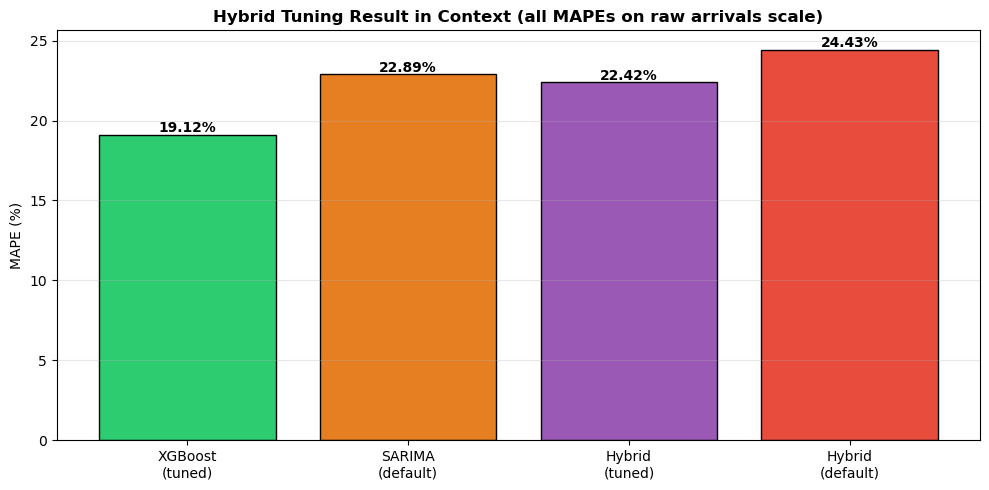

Saved: ../results/11_hybrid_tuning.png


In [6]:
fig, ax = plt.subplots(figsize=(10,5))
models = ['XGBoost\n(tuned)','SARIMA\n(default)','Hybrid\n(tuned)','Hybrid\n(default)']
mapes  = [19.12, 22.89, tuned_mape, 24.43]
colors = ['#2ecc71','#e67e22','#9b59b6','#e74c3c']
bars = ax.bar(models, mapes, color=colors, edgecolor='black')
for b,v in zip(bars, mapes):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.15, f'{v:.2f}%', ha='center', fontweight='bold')
ax.set_title('Hybrid Tuning Result in Context (all MAPEs on raw arrivals scale)', fontweight='bold')
ax.set_ylabel('MAPE (%)'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/11_hybrid_tuning.png', dpi=150)
plt.show()
print("Saved: ../results/11_hybrid_tuning.png")